In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / 'data' / 'dataset.csv'

df = pd.read_csv(DATA_PATH)

In [3]:
df.shape

(12000, 3)

In [4]:
df.head()

,ticket_description,category,priority
0,Network outage reported during peak working ho...,Network,Low
1,Cannot connect to WiFi network on the office l...,Network,Low
2,Network outage reported affecting critical bus...,Network,Low
3,Internet connection is very slow since this mo...,Network,Low
4,LAN connection is not detected reported by sev...,Network,Low


In [5]:
df.tail()

,ticket_description,category,priority
11995,Permission issue while accessing internal syst...,Access,High
11996,Unauthorized access attempt detected since thi...,Access,Low
11997,User forgot system password during peak workin...,Access,Medium
11998,Unauthorized access attempt detected after the...,Access,Medium
11999,Access denied when opening shared folder repor...,Access,High


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ticket_description  12000 non-null  object
 1   category            12000 non-null  object
 2   priority            12000 non-null  object
dtypes: object(3)
memory usage: 281.4+ KB


In [7]:
df.isnull().sum()

ticket_description    0
category              0
priority              0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df['category'].value_counts()

category
Network     3000
Software    3000
Hardware    3000
Access      3000
Name: count, dtype: int64

<Axes: xlabel='category'>

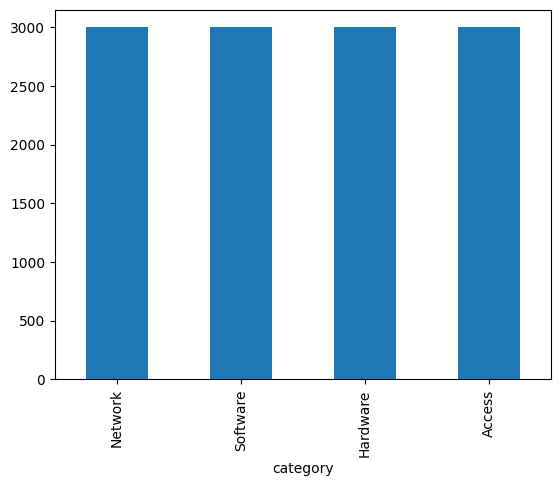

In [10]:
df['category'].value_counts().plot(kind='bar')

In [11]:
df['priority'].value_counts(normalize=True)


priority
Low       0.44675
Medium    0.35025
High      0.20300
Name: proportion, dtype: float64

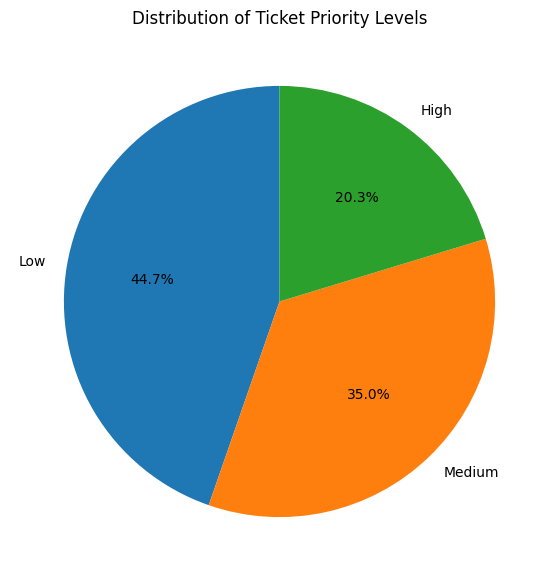

In [12]:
priority_counts = df["priority"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    priority_counts,
    labels=priority_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribution of Ticket Priority Levels")
plt.show()

In [13]:
df['char_len'] = df['ticket_description'].str.len()
df['word_len'] = df['ticket_description'].str.split().apply(len)

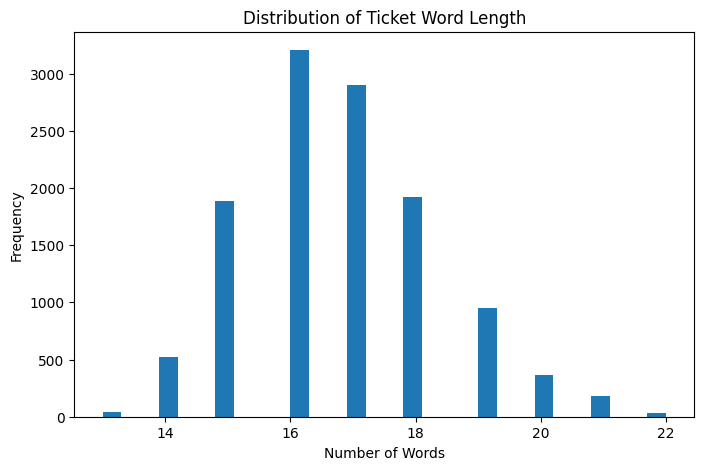

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df["word_len"], bins=30)
plt.title("Distribution of Ticket Word Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

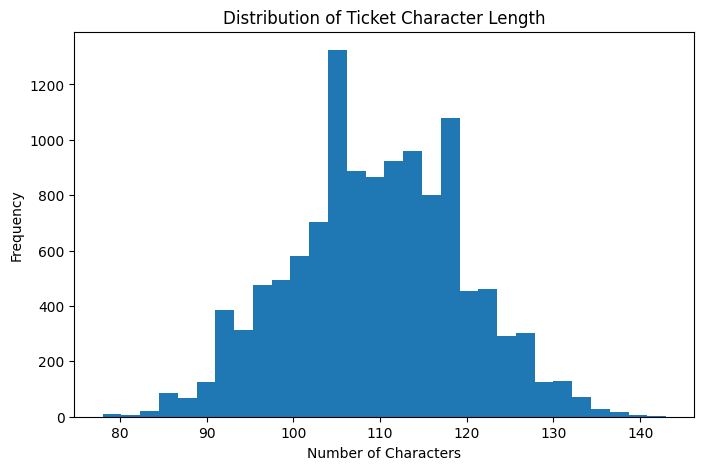

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df["char_len"], bins=30)
plt.title("Distribution of Ticket Character Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

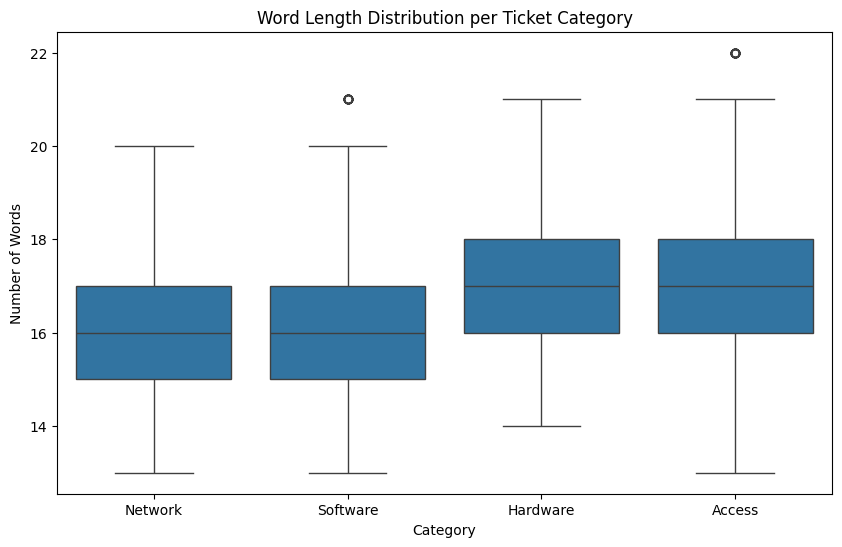

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="category",
    y="word_len"
)
plt.title("Word Length Distribution per Ticket Category")
plt.xlabel("Category")
plt.ylabel("Number of Words")
plt.show()


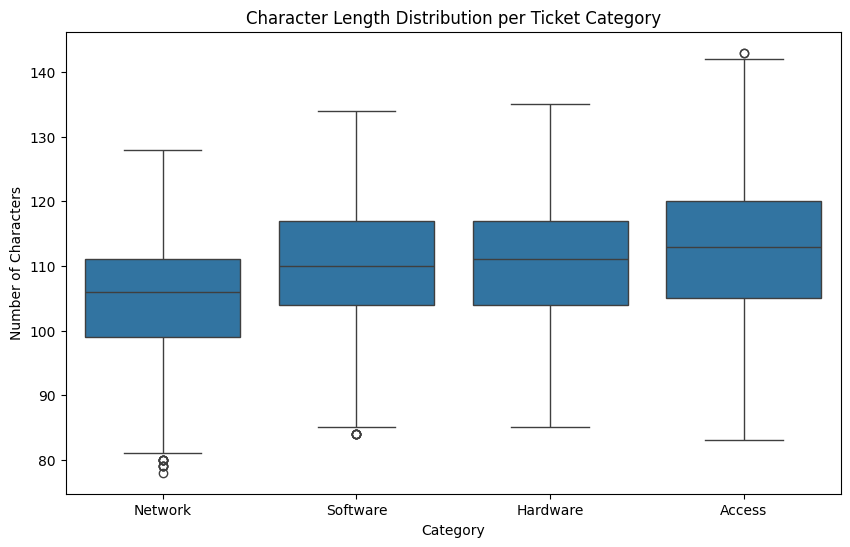

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="category",
    y="char_len"
)
plt.title("Character Length Distribution per Ticket Category")
plt.xlabel("Category")
plt.ylabel("Number of Characters")
plt.show()
